In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Getting Started with Image Processing with Python.**

Exercise 1:

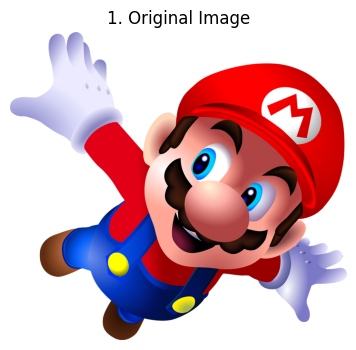

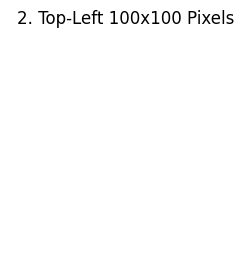

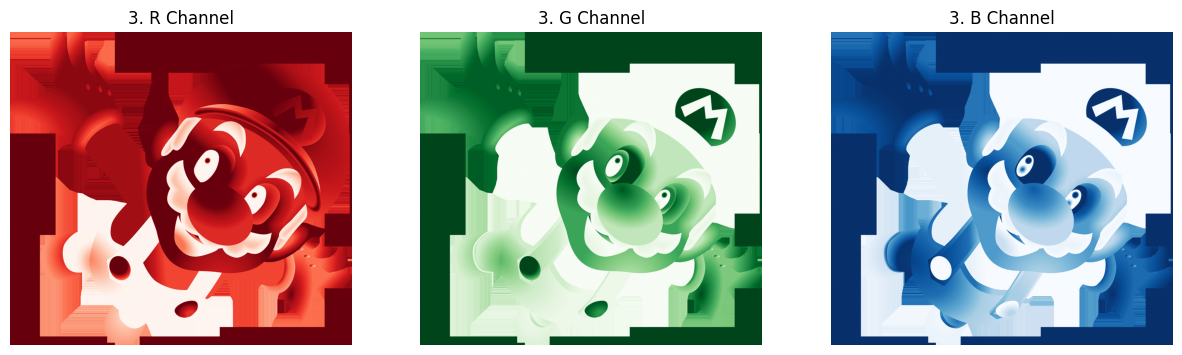

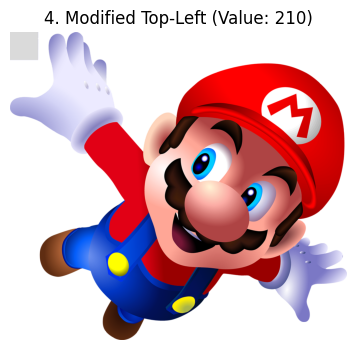

In [2]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load a sample image (replace with your image path)
image_path = "/content/drive/MyDrive/mario_PNG125.png"

# ==========================================
# 1. Read and display the image
# ==========================================
img = Image.open(image_path)
img_arr = np.array(img)

plt.figure(figsize=(6, 4))
plt.imshow(img_arr)
plt.title("1. Original Image")
plt.axis('off')
plt.show()

# ==========================================
# 2. Display only the top left corner (100x100)
# ==========================================
top_left_100 = img_arr[:100, :100]

plt.figure(figsize=(3, 3))
plt.imshow(top_left_100)
plt.title("2. Top-Left 100x100 Pixels")
plt.axis('off')
plt.show()

# ==========================================
# 3. Show the three color channels (R, G, B)
# ==========================================
# Extract channels (0: Red, 1: Green, 2: Blue)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# We map them using their respective colormaps for clear visualization
axes[0].imshow(img_arr[:, :, 0], cmap='Reds')
axes[0].set_title('3. R Channel')
axes[0].axis('off')

axes[1].imshow(img_arr[:, :, 1], cmap='Greens')
axes[1].set_title('3. G Channel')
axes[1].axis('off')

axes[2].imshow(img_arr[:, :, 2], cmap='Blues')
axes[2].set_title('3. B Channel')
axes[2].axis('off')

plt.show()

# ==========================================
# 4. Modify the top 100x100 pixels to 210
# ==========================================
img_modified = img_arr.copy()
# Set all RGB channels of the top-left 100x100 block to 210 (light gray)
img_modified[:100, :100] = 210

plt.figure(figsize=(6, 4))
plt.imshow(img_modified)
plt.title("4. Modified Top-Left (Value: 210)")
plt.axis('off')
plt.show()

Exercise 2:

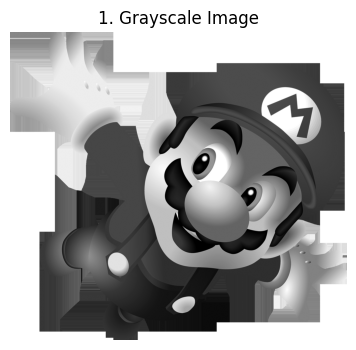

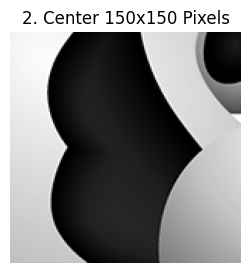

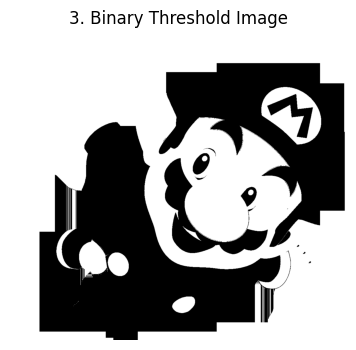

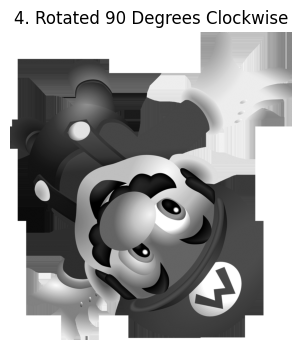

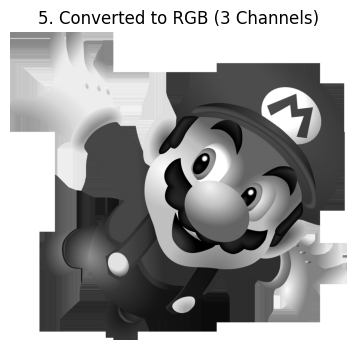

In [3]:
# ==========================================
# 1. Load and display a grayscale image
# ==========================================
# Convert image to grayscale using Pillow ('L' mode)
img_gray = Image.open(image_path).convert('L')
img_gray_arr = np.array(img_gray)

plt.figure(figsize=(6, 4))
plt.imshow(img_gray_arr, cmap='gray')
plt.title("1. Grayscale Image")
plt.axis('off')
plt.show()

# ==========================================
# 2. Extract and display the middle section (150x150 pixels)
# ==========================================
h, w = img_gray_arr.shape
center_y, center_x = h // 2, w // 2

# Calculate bounds for a 150x150 patch (75 pixels in each direction from center)
middle_150 = img_gray_arr[center_y-75 : center_y+75, center_x-75 : center_x+75]

plt.figure(figsize=(3, 3))
plt.imshow(middle_150, cmap='gray')
plt.title("2. Center 150x150 Pixels")
plt.axis('off')
plt.show()

# ==========================================
# 3. Apply a simple threshold (binary image)
# ==========================================
# Values < 100 become 0 (black), otherwise 255 (white)
binary_img = np.where(img_gray_arr < 100, 0, 255)

plt.figure(figsize=(6, 4))
plt.imshow(binary_img, cmap='gray')
plt.title("3. Binary Threshold Image")
plt.axis('off')
plt.show()

# ==========================================
# 4. Rotate the image 90 degrees clockwise
# ==========================================
# Pillow's rotate function applies counter-clockwise rotation, so we use -90
rotated_img = img_gray.rotate(-90, expand=True)

plt.figure(figsize=(6, 4))
plt.imshow(rotated_img, cmap='gray')
plt.title("4. Rotated 90 Degrees Clockwise")
plt.axis('off')
plt.show()

# ==========================================
# 5. Convert the grayscale image to an RGB image
# ==========================================
# Stack the 2D grayscale array 3 times along a new depth axis
rgb_from_gray = np.stack((img_gray_arr,) * 3, axis=-1)

plt.figure(figsize=(6, 4))
plt.imshow(rgb_from_gray)
plt.title("5. Converted to RGB (3 Channels)")
plt.axis('off')
plt.show()

Image Compression and Decompression using PCA.

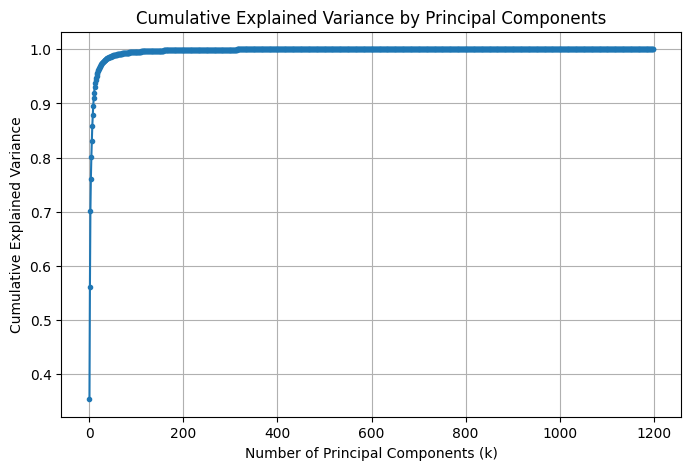

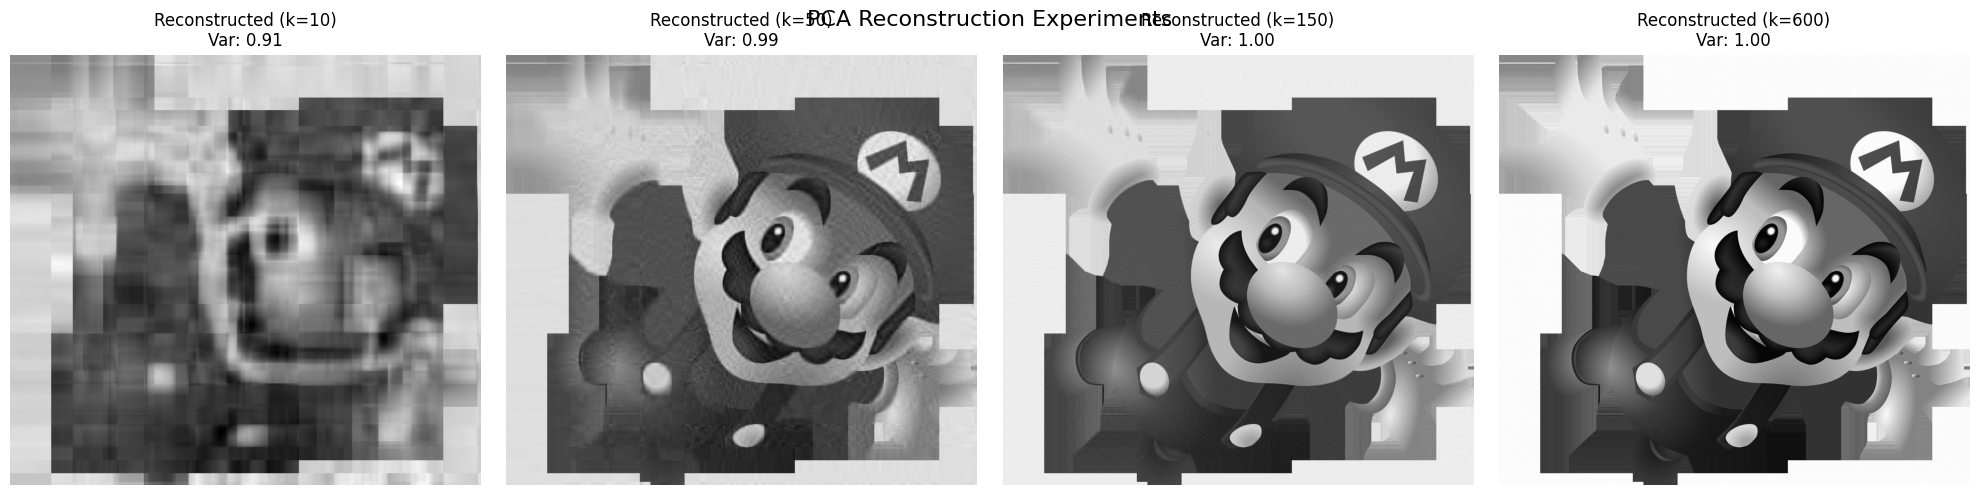

In [4]:
# ==========================================
# 1. Load and Prepare Data
# ==========================================
# Fetch image and convert to grayscale
original_img = Image.open(image_path).convert('L')
X = np.array(original_img, dtype=np.float64)

# Center the dataset (Standardize data by subtracting the mean of each column)
mean_X = np.mean(X, axis=0)
X_centered = X - mean_X

# Calculate the covariance matrix of the standardized data
# rowvar=False treats columns as variables (features)
cov_matrix = np.cov(X_centered, rowvar=False)

# ==========================================
# 2. Eigen Decomposition & Identifying PCs
# ==========================================
# Compute Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort eigenvalues in descending order and rearrange eigenvectors accordingly
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Cumulative Sum Plot for Explained Variance
explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, marker='o', markersize=3)
plt.title("Cumulative Explained Variance by Principal Components")
plt.xlabel("Number of Principal Components (k)")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

# ==========================================
# 3. Reconstruction and Experiment
# ==========================================
def reconstruct_image(X_centered, mean_vector, eigenvectors, k):
    """Transforms data to lower dimensions and reconstructs the image."""
    # Choose top k eigenvectors (Principal Components)
    top_k_eigenvectors = eigenvectors[:, :k]

    # Transformation: project original data onto lower-dimensional space
    X_reduced = np.dot(X_centered, top_k_eigenvectors)

    # Reconstruction: project back to original dimensional space and add mean
    X_reconstructed = np.dot(X_reduced, top_k_eigenvectors.T) + mean_vector
    return X_reconstructed

# Experiment: Pick four different combinations of principal components
# Note: Adjust these k_values based on your image resolution (e.g., width of image)
k_values = [10, 50, 150, X.shape[1] // 2]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, k in enumerate(k_values):
    # Make sure k doesn't exceed the number of features
    k_actual = min(k, X.shape[1])
    reconstructed_img = reconstruct_image(X_centered, mean_X, eigenvectors, k_actual)

    axes[i].imshow(reconstructed_img, cmap='gray')
    axes[i].set_title(f"Reconstructed (k={k_actual})\nVar: {cumulative_variance[k_actual-1]:.2f}")
    axes[i].axis('off')

plt.suptitle("PCA Reconstruction Experiments", fontsize=16)
plt.tight_layout()
plt.show()